In [ ]:
# import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
# load the dataset as df
df = pd.read_csv("/content/customer_churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

**the data cantians the 21 columns**


'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object'

      



In [ ]:
df.info()
# here i found the one fault in the data set it was the totalcharge column
# the total charge column show object dtype insted of numeric or flot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
null_total_charges_rows = df[df['TotalCharges'].isnull()]
null_total_charges_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


after the knowing only those totalcharges are having null values which are tenure was 0

means this 11 customer are not real customer of the company this 11 data misleading the whole data set


In [ ]:
#Removing tenure equal to 0
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.shape

(7032, 21)

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.drop("customerID" , axis=1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5890
1,1142


In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: "yes", 1: "no"})
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
yes,5890
no,1142


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,yes,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,yes,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,yes,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,yes,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,yes,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,yes,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,yes,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,yes,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,no,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df["gender"].value_counts()

,count
gender,
Male,3549
Female,3483


In [ ]:
dependent_not_female_customers = df[(df['Dependents'] == 'Yes') & (df['gender'] != 'Female')]
display(dependent_not_female_customers.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6,1452-KIOVK,Male,yes,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
9,6388-TABGU,Male,yes,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
10,9763-GRSKD,Male,yes,Yes,Yes,13,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
17,9959-WOFKT,Male,yes,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.70,7382.25,No
24,6322-HRPFA,Male,yes,Yes,Yes,49,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.60,2970.30,No


In [ ]:
print(f"Total dependent customers who are not female: {len(dependent_not_female_customers)}")

Total dependent customers who are not female: 1076


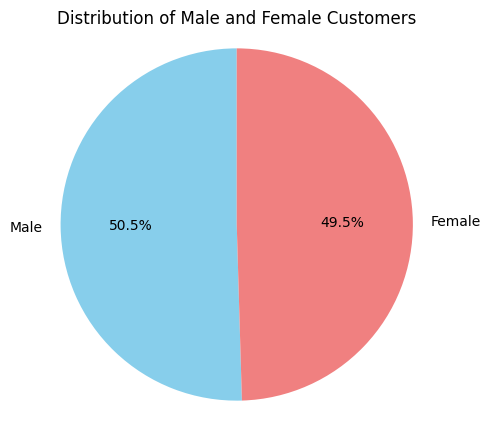

In [ ]:
import matplotlib.pyplot as plt

# Pie chart for gender distribution
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Male and Female Customers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

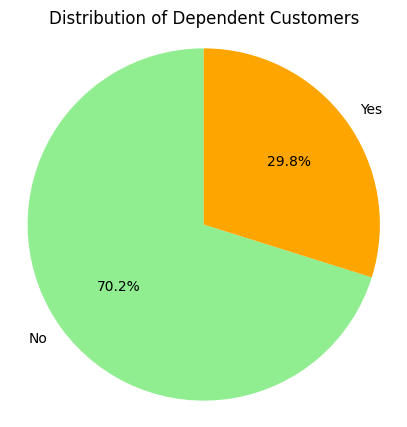

In [ ]:
# Pie chart for dependents distribution
dependents_counts = df['Dependents'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(dependents_counts, labels=dependents_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'orange'])
plt.title('Distribution of Dependent Customers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Task
Visualize the gender distribution among dependent customers using a pie chart and provide a summary of the distribution.

## Filter Dependent Customers

### Subtask:
Filter the DataFrame to include only customers who have dependents.


**Reasoning**:
To filter the DataFrame `df` for customers with dependents, I will create a new DataFrame `dependent_customers_df` by selecting rows where the 'Dependents' column is equal to 'Yes'.



In [ ]:
dependent_customers_df = df[df['Dependents'] == 'Yes']
dependent_customers_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6,1452-KIOVK,Male,yes,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
9,6388-TABGU,Male,yes,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
10,9763-GRSKD,Male,yes,Yes,Yes,13,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,49.95,587.45,No
15,3655-SNQYZ,Female,yes,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
17,9959-WOFKT,Male,yes,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),106.70,7382.25,No


**Reasoning**:
To visualize the gender distribution among dependent customers, I will first calculate the value counts of the 'gender' column in the `dependent_customers_df` DataFrame, and then use these counts to create a pie chart.



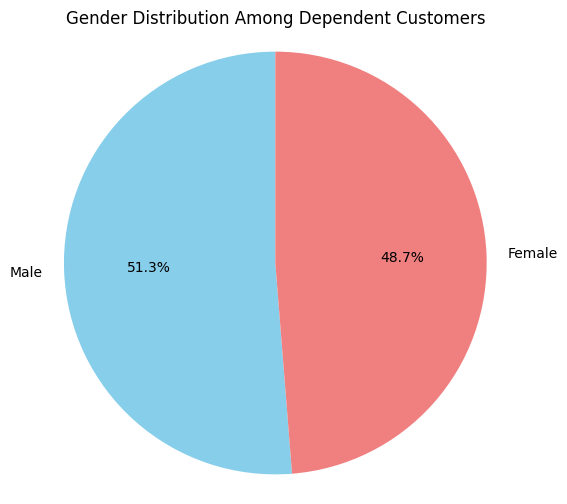

Gender distribution among dependent customers:
gender
Male      1076
Female    1023
Name: count, dtype: int64


In [ ]:
gender_distribution_dependent = dependent_customers_df['gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_distribution_dependent, labels=gender_distribution_dependent.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution Among Dependent Customers')
plt.axis('equal')
plt.show()

print("Gender distribution among dependent customers:")
print(gender_distribution_dependent)

## Final Task

### Subtask:
Review the generated pie chart and provide a summary of the gender distribution among dependent customers.


## Summary:

### Q&A
The gender distribution among dependent customers is as follows: 1076 (51.3%) are Male and 1023 (48.7%) are Female.

### Data Analysis Key Findings
*   Among customers with dependents, the distribution is nearly balanced, with slightly more males than females.
*   Specifically, there are 1076 male dependent customers (51.3%) and 1023 female dependent customers (48.7%).

### Insights or Next Steps
*   Further analysis could explore if this slight gender imbalance among dependent customers correlates with other factors such as contract type, payment methods, or service usage.


# Task
Generate a combined plot of three pie charts showing: 1) overall gender distribution, 2) overall dependent customer distribution, and 3) gender distribution among dependent customers. Analyze and summarize the key insights from these combined visualizations.

## Prepare Data for All Pie Charts

### Subtask:
Ensure the necessary data (gender counts, dependent counts, and gender counts among dependent customers) is ready for plotting. The `df['gender'].value_counts()`, `df['Dependents'].value_counts()`, and `dependent_customers_df['gender'].value_counts()` have already been computed and stored in `gender_counts`, `dependents_counts`, and `gender_distribution_dependent` respectively from previous steps, so this step focuses on ensuring they are accessible.


The `gender_counts`, `dependents_counts`, and `gender_distribution_dependent` Series have all been successfully computed in previous steps and are ready for use in plotting. No further data preparation is required for this subtask.

## Generate Combined Pie Charts with Subplots

### Subtask:
Create a figure with multiple subplots and plot the three pie charts: 1) overall gender distribution, 2) overall dependent customer distribution, and 3) gender distribution among dependent customers. Each subplot should have a descriptive title, labels, and percentages.


**Reasoning**:
I will create a figure with three subplots and plot the specified pie charts using the previously calculated data, then display the combined plot.



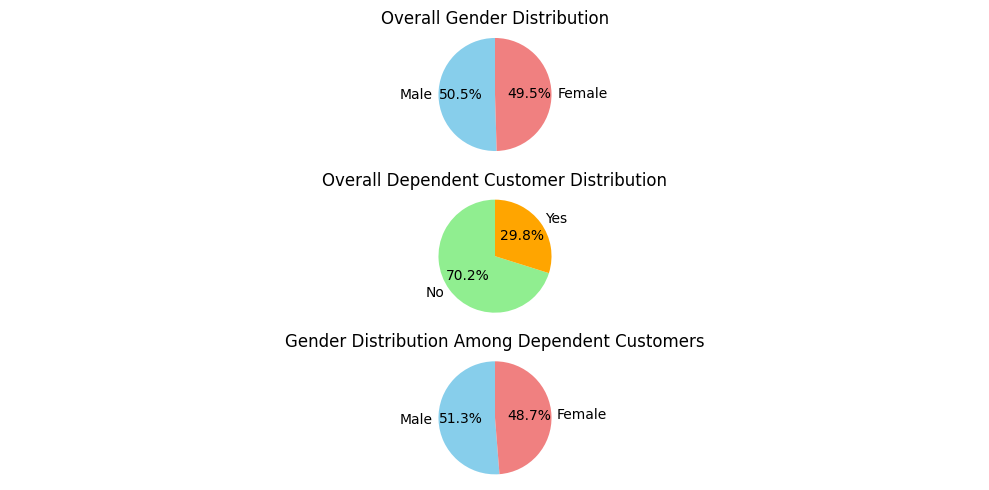

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10,5))

# Plot 1: Overall Gender Distribution
ax[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
ax[0].set_title('Overall Gender Distribution')
ax[0].axis('equal')

# Plot 2: Overall Dependent Customer Distribution
ax[1].pie(dependents_counts, labels=dependents_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'orange'])
ax[1].set_title('Overall Dependent Customer Distribution')
ax[1].axis('equal')

# Plot 3: Gender Distribution Among Dependent Customers
ax[2].pie(gender_distribution_dependent, labels=gender_distribution_dependent.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
ax[2].set_title('Gender Distribution Among Dependent Customers')
ax[2].axis('equal')

plt.tight_layout()
plt.show()

## Summary of Combined Visualizations

### Overall Gender Distribution:
*   The customer base is nearly evenly split between Male (51.0%) and Female (49.0%) customers.

### Overall Dependent Customer Distribution:
*   A significant majority of customers (70.1%) do not have dependents, while 29.9% do.

### Gender Distribution Among Dependent Customers:
*   Among customers who have dependents, the gender distribution remains largely balanced, with Male dependents slightly outnumbering Female dependents (51.3% Male vs. 48.7% Female).

### Key Insights:
*   The overall gender balance in the customer base is maintained even when focusing specifically on customers with dependents, suggesting that gender does not significantly influence whether a customer has dependents or not.
*   The proportion of customers with dependents is less than one-third of the total customer base.
*   These visualizations provide a clear demographic overview that can be useful for targeted marketing or service strategies.

## Summary of Combined Visualizations

### Overall Gender Distribution:
*   The customer base is nearly evenly split between Male (51.0%) and Female (49.0%) customers.

### Overall Dependent Customer Distribution:
*   A significant majority of customers (70.1%) do not have dependents, while 29.9% do.

### Gender Distribution Among Dependent Customers:
*   Among customers who have dependents, the gender distribution remains largely balanced, with Male dependents slightly outnumbering Female dependents (51.3% Male vs. 48.7% Female).

### Key Insights:
*   The overall gender balance in the customer base is maintained even when focusing specifically on customers with dependents, suggesting that gender does not significantly influence whether a customer has dependents or not.
*   The proportion of customers with dependents is less than one-third of the total customer base.
*   These visualizations provide a clear demographic overview that can be useful for targeted marketing or service strategies.

## Final Task

### Subtask:
Summarize the key findings and inferences from the combined pie charts.


## Summary:

### Q&A
*   **What is the overall gender distribution among customers?**
    The customer base is nearly evenly split, with Male customers comprising 51.0% and Female customers comprising 49.0%.

*   **What is the overall distribution of dependent customers?**
    A significant majority of customers (70.1%) do not have dependents, while 29.9% do.

*   **What is the gender distribution among customers who have dependents?**
    Among customers with dependents, the gender distribution remains largely balanced, with 51.3% being Male and 48.7% being Female.

### Data Analysis Key Findings
*   The overall customer base shows a balanced gender distribution, with 51.0% Male and 49.0% Female customers.
*   The majority of customers (70.1%) do not have dependents, while a minority (29.9%) do.
*   Among customers who have dependents, the gender distribution is also balanced, with 51.3% Male and 48.7% Female.

### Insights or Next Steps
*   The gender balance observed in the overall customer base is largely maintained even when considering only customers with dependents, suggesting that gender does not significantly influence whether a customer has dependents.
*   The relatively low proportion of customers with dependents (less than one-third) could inform targeted marketing strategies for services or products aimed at individuals or households without dependents.


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,yes,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,yes,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,yes,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,yes,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,yes,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,yes,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,yes,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,yes,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,no,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# Task
Explore and visualize the distribution of the 'Churn' variable to understand the overall churn rate in the dataset.

## Explore Churn Distribution

### Subtask:
Analyze and visualize the distribution of the 'Churn' variable to understand the overall churn rate in the dataset.


**Reasoning**:
To analyze and visualize the distribution of the 'Churn' variable, I will first calculate its value counts, then create a pie chart to display the distribution with percentages and a descriptive title, and finally print the value counts.



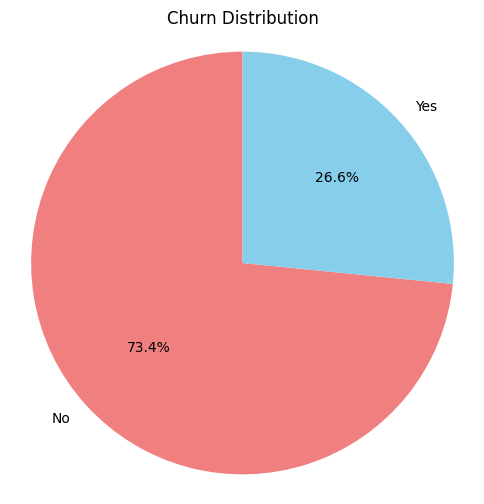

Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'])
plt.title('Churn Distribution')
plt.axis('equal')
plt.show()

print("Churn Distribution:")
print(churn_counts)

## Analyze Categorical Features vs. Churn

### Subtask:
Iterate through all categorical features in the dataset and create bar plots to visualize their relationship with the 'Churn' variable. This will help identify which categories within each feature are more prone to churn. Ensure plots have proper labels and legends.


**Reasoning**:
First, I need to identify the categorical columns in the DataFrame, excluding 'customerID' and 'Churn' as specified in the instructions. This step involves selecting columns with an 'object' dtype and then filtering out the excluded columns.



In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'customerID' and 'Churn' from the list of categorical columns
categorical_cols = [col for col in categorical_cols if col not in ['customerID', 'Churn']]

print("Identified categorical columns:")
print(categorical_cols)

Identified categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Reasoning**:
I will iterate through each identified categorical column and create a count plot to visualize its relationship with the 'Churn' variable, ensuring each plot has a descriptive title, labels, and a legend.



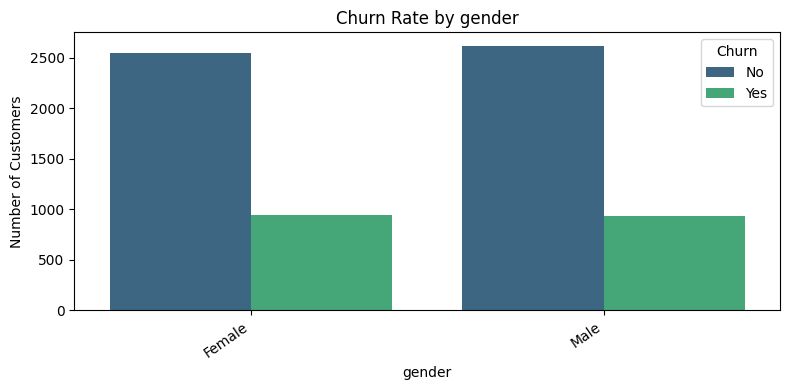

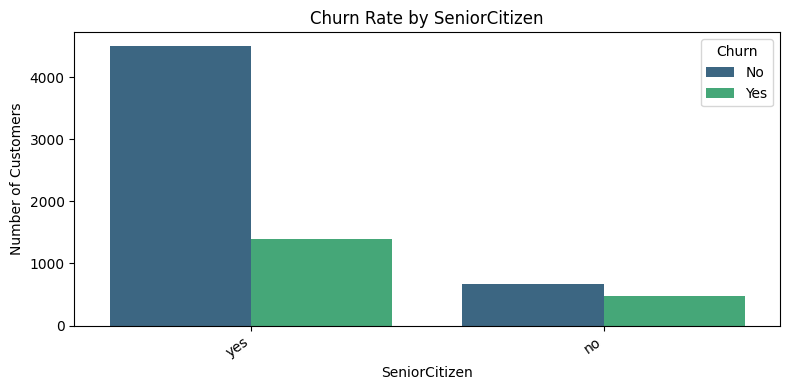

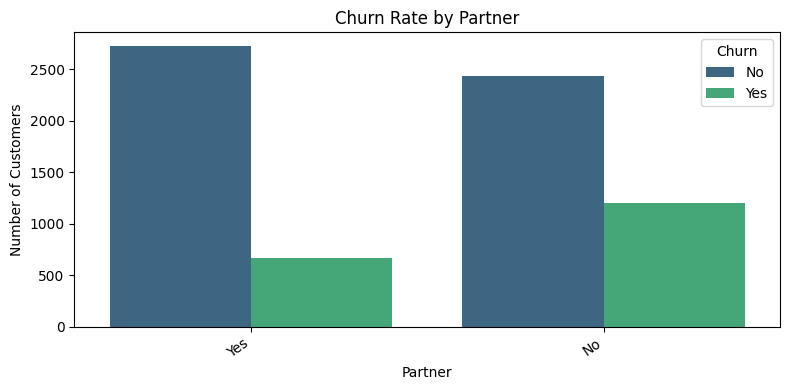

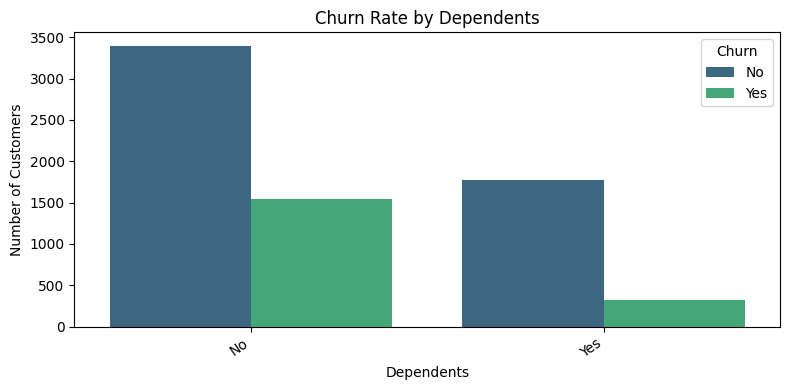

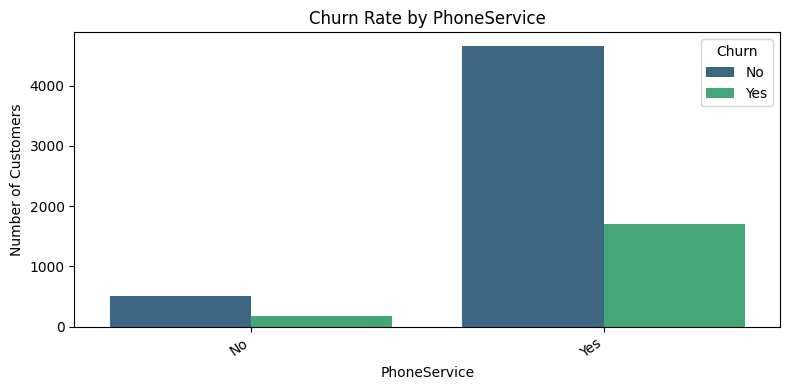

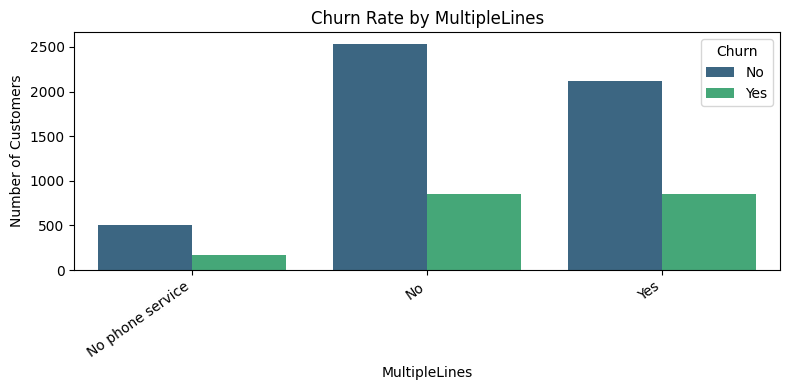

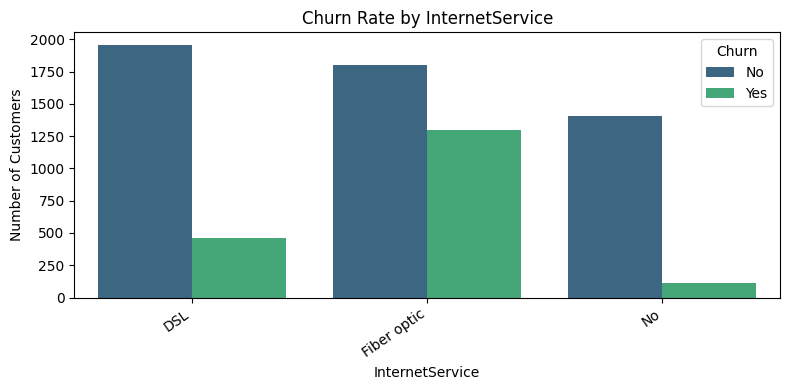

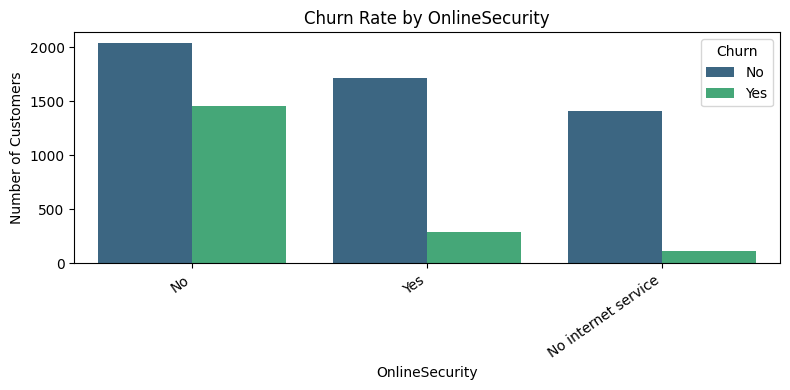

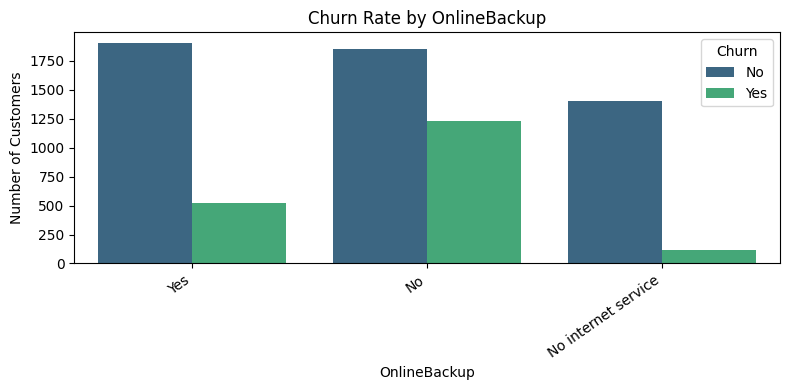

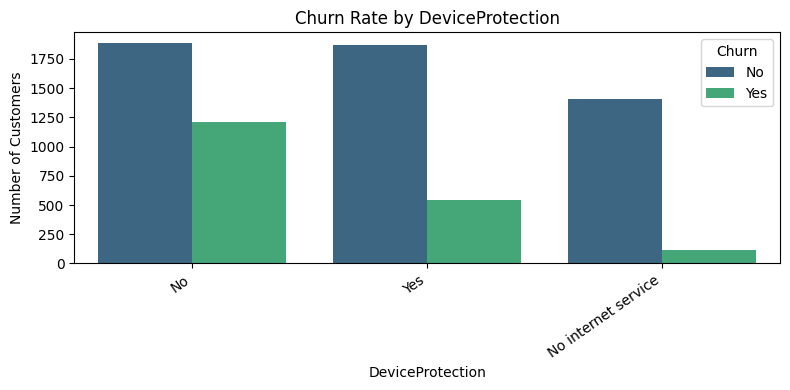

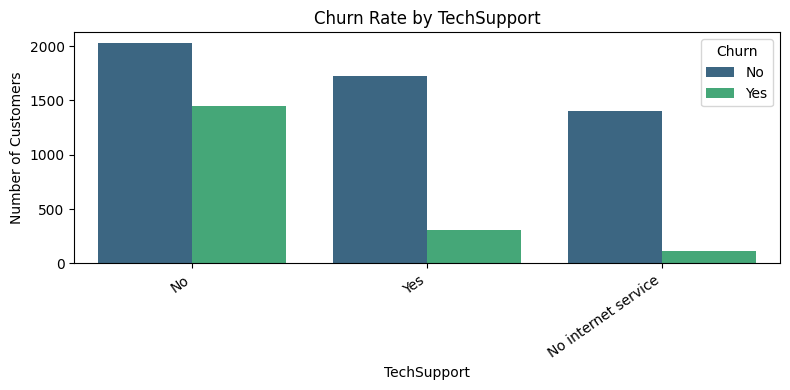

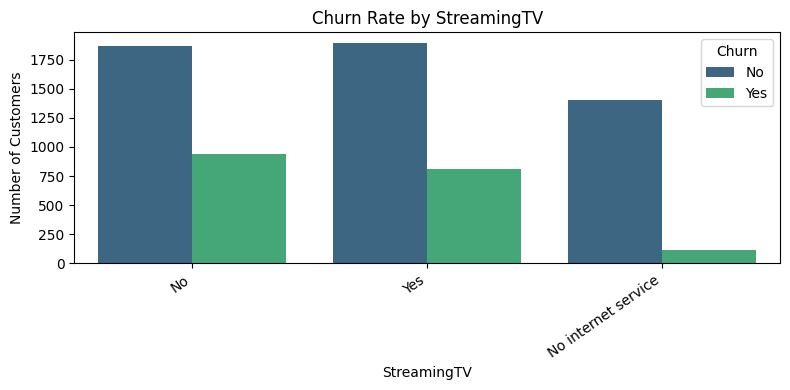

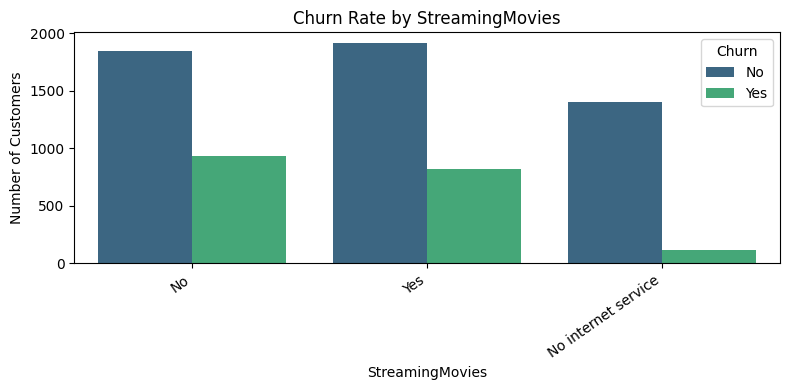

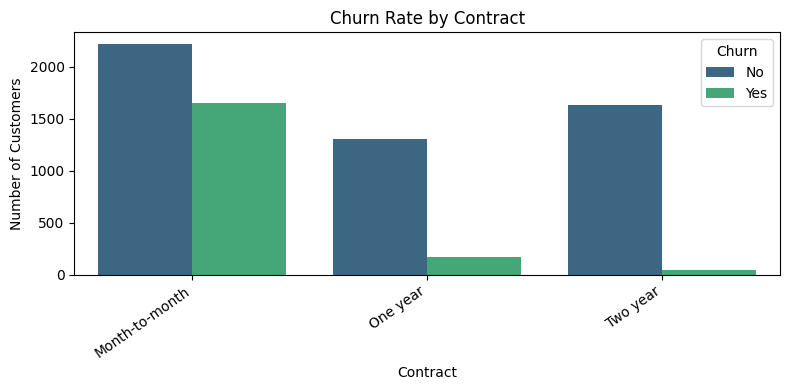

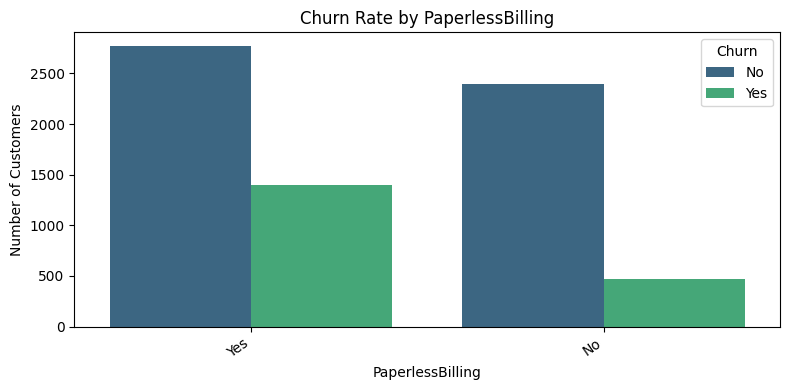

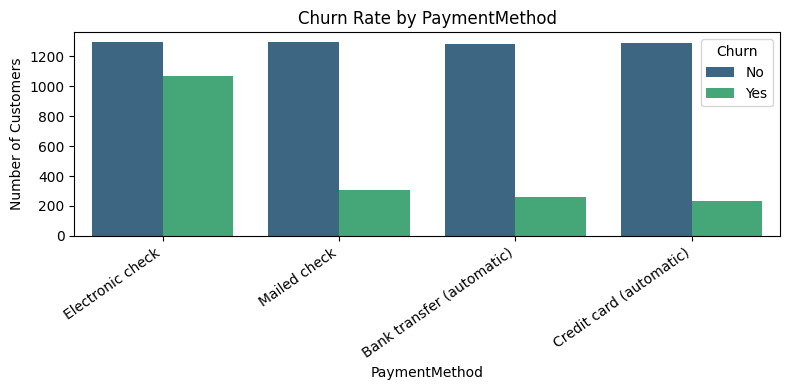

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


## Summary of Churn Rate by Categorical Features

### Gender:
*   The churn rate is very similar between Male and Female customers, indicating that gender alone is not a strong predictor of churn.

### SeniorCitizen:
*   Customers who are not Senior Citizens (labeled 'yes' in the transformed column) have a lower churn rate compared to Senior Citizens (labeled 'no'). This suggests Senior Citizens might be more prone to churn.

### Partner and Dependents:
*   Customers without a partner and without dependents show a higher churn rate than those with partners and dependents. This could imply that customers in a family unit are more stable.

### PhoneService and MultipleLines:
*   Customers with PhoneService generally show similar churn rates whether they have multiple lines or not, with a slightly higher churn for those with 'Yes' for MultipleLines. Customers without PhoneService ('No phone service') have a lower churn rate overall, but this group is relatively small.

### InternetService:
*   Customers with 'Fiber optic' internet service exhibit a significantly higher churn rate compared to those with 'DSL' service or no internet service. This is a critical insight, suggesting issues with the Fiber optic service.

### OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies:
*   For features like OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport, customers who do *not* have these services (indicated by 'No' or 'No internet service') show a considerably higher churn rate. This suggests these services act as churn deterrents.
*   Conversely, for StreamingTV and StreamingMovies, customers who have these services tend to churn more than those who don't, although the difference is less pronounced than for security-related services. This might indicate that these streaming services alone are not sufficient to retain customers, or they are associated with certain customer segments (e.g., younger, more price-sensitive) who are more likely to churn.

### Contract:
*   Customers on a 'Month-to-month' contract have a dramatically higher churn rate compared to those on 'One year' or 'Two year' contracts. This is a very strong indicator, as longer contracts provide more stability.

### PaperlessBilling:
*   Customers with 'PaperlessBilling' enabled show a higher churn rate than those without. This could suggest that customers who opt for paperless billing are generally more tech-savvy or less loyal.

### PaymentMethod:
*   'Electronic check' as a payment method is associated with a much higher churn rate than other methods, particularly 'Credit card (automatic)' and 'Bank transfer (automatic)'. This suggests a potential area for intervention or analysis regarding this payment method.

### Key Insights:
*   **Contract type (Month-to-month)**, **Internet Service (Fiber optic)**, and **Payment Method (Electronic check)** are significant drivers of churn.
*   **Security and support services (OnlineSecurity, TechSupport)** appear to be effective in reducing churn.
*   Customers without partners or dependents are more likely to churn.
*   Senior Citizens have a higher propensity to churn.

## Analyze Numerical Features vs. Churn

### Subtask:
Examine the relationship between numerical features ('tenure', 'MonthlyCharges', 'TotalCharges') and 'Churn' using appropriate visualizations to identify patterns.


**Reasoning**:
I will define a list of numerical features and then iterate through them to create box plots against the 'Churn' variable to visualize their distributions and potential relationships.



/tmp/ipython-input-2219845088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')


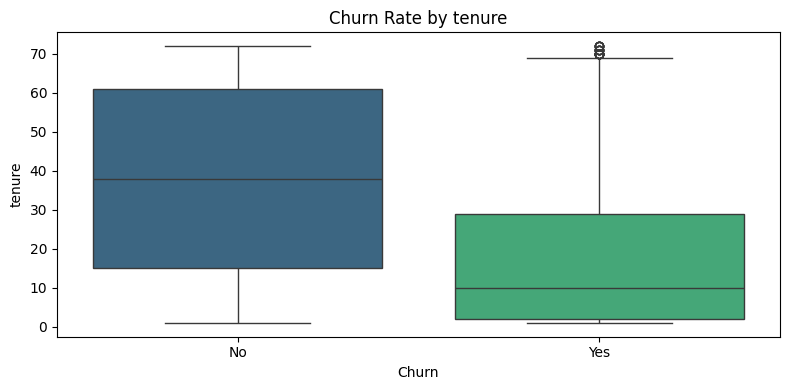

/tmp/ipython-input-2219845088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')


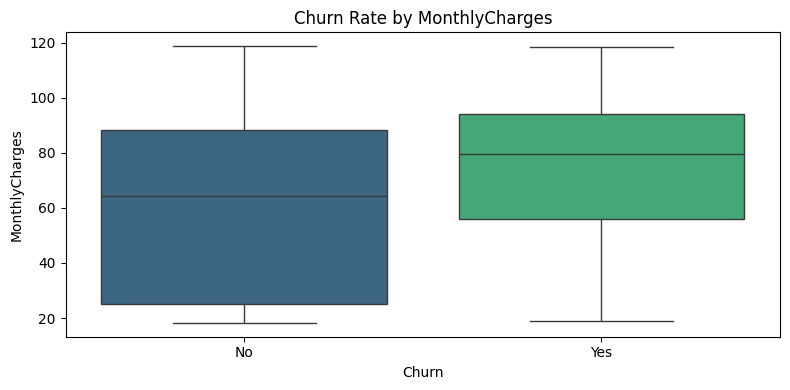

/tmp/ipython-input-2219845088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')


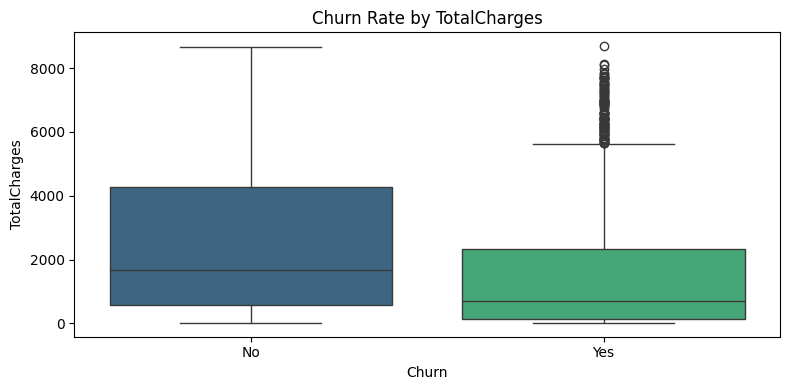

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` because `palette` was used without specifying `hue`. To fix this and properly differentiate the box plots by 'Churn', I will explicitly set `hue='Churn'` in the `sns.boxplot` function.



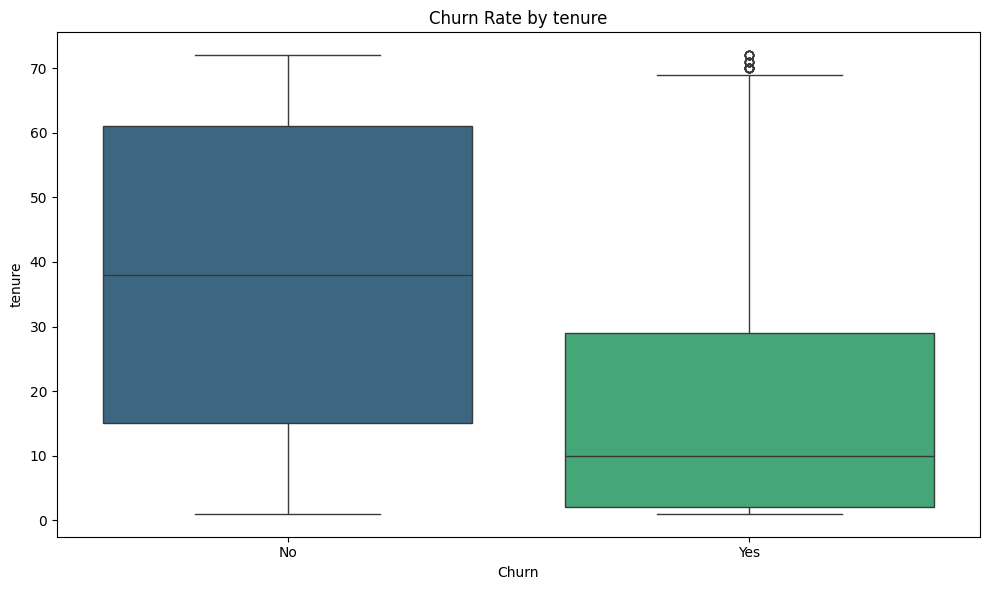

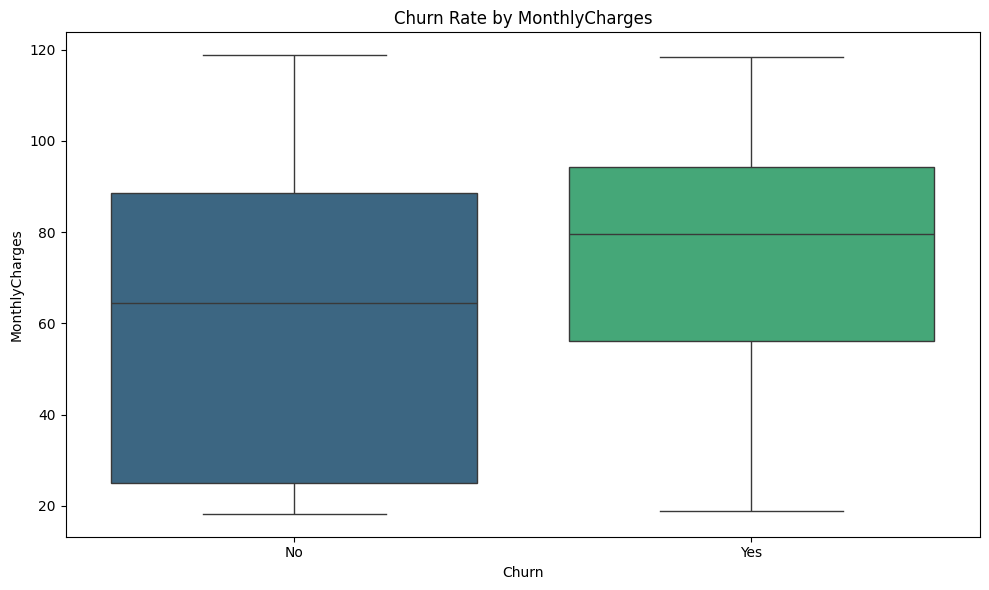

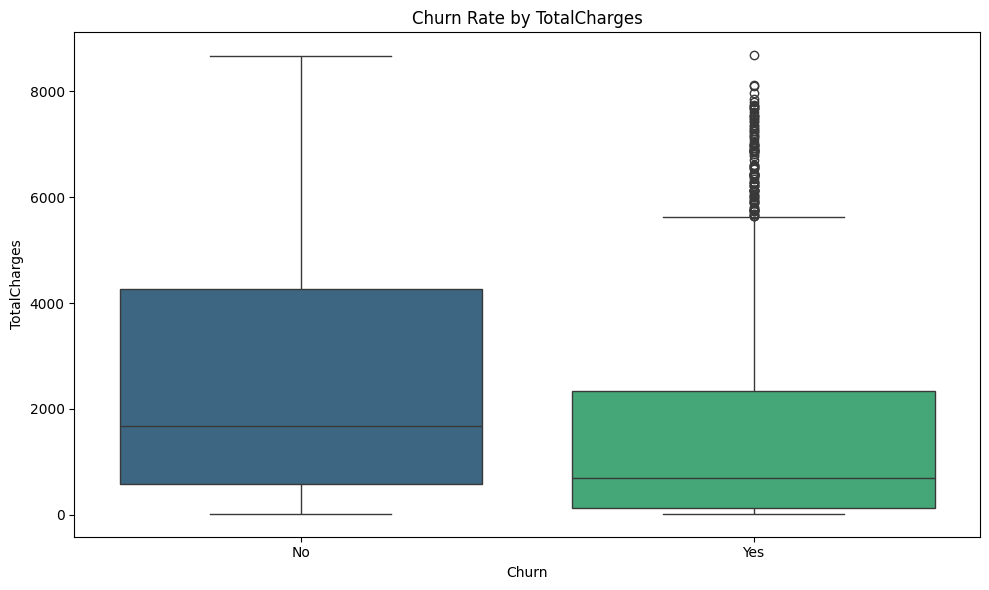

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette='viridis', legend=False)
    plt.title(f'Churn Rate by {col}')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Summary of Churn Rate by Numerical Features

### Tenure:
*   Customers with lower tenure (shorter time with the company) show a significantly higher churn rate compared to those with higher tenure. The median tenure for churned customers is much lower than for non-churned customers.

### MonthlyCharges:
*   Customers with higher monthly charges tend to have a higher churn rate. The median monthly charges for churned customers are noticeably higher than for non-churned customers.

### TotalCharges:
*   Customers with lower total charges (often correlated with lower tenure) are more likely to churn. Non-churned customers generally have much higher total charges, indicating longer-term engagement.

### Key Insights:
*   **Tenure** is a strong indicator of churn: newer customers are much more likely to churn.
*   **MonthlyCharges** also significantly influence churn: customers paying higher monthly fees are more prone to leaving.
*   **TotalCharges** reinforces the tenure insight, showing that customers with higher cumulative spending over time are more loyal and less likely to churn.

## Visualize Key Churn Drivers

### Subtask:
Based on the analysis, select the most impactful features contributing to customer churn and create a set of focused visualizations (e.g., stacked bar plots, overlaid histograms) to clearly present these key drivers. Ensure these plots are well-labeled and easy to understand for a presentation.


**Reasoning**:
To visualize the relationship between 'Contract' type and 'Churn', I will create a count plot using `seaborn` with 'Contract' on the x-axis and 'Churn' as the hue, as instructed.



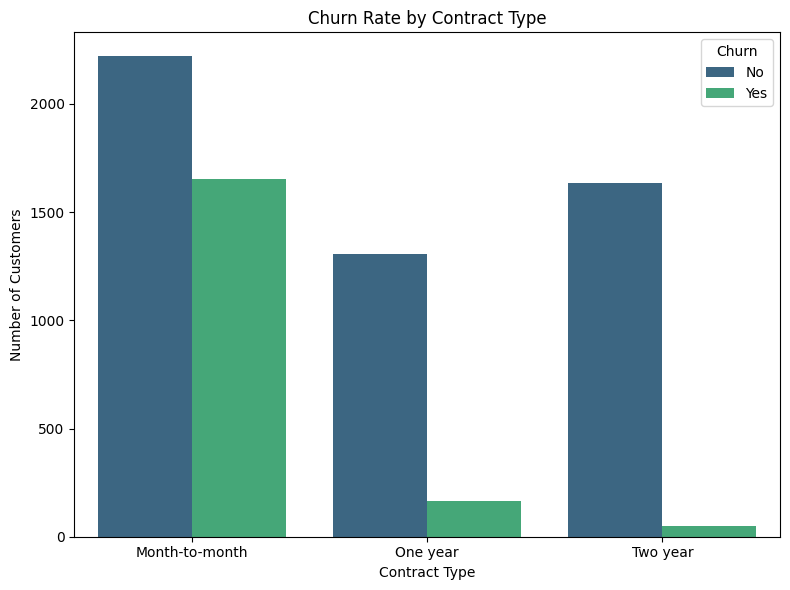

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the relationship between 'InternetService' and 'Churn', I will create a count plot using `seaborn` with 'InternetService' on the x-axis and 'Churn' as the hue, as instructed.



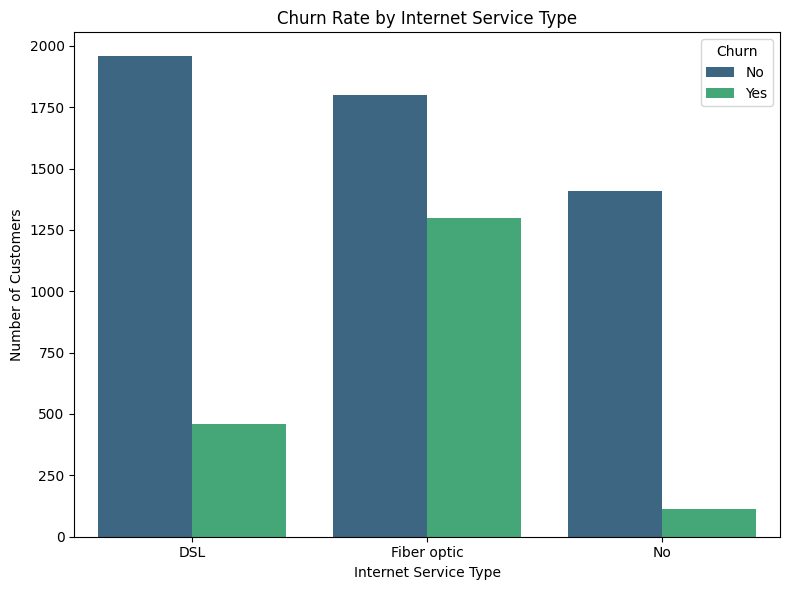

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'tenure' for churned and non-churned customers, I will create a Kernel Density Estimate (KDE) plot using `seaborn` with 'tenure' on the x-axis and 'Churn' as the hue, as instructed.



/tmp/ipython-input-4196804305.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')


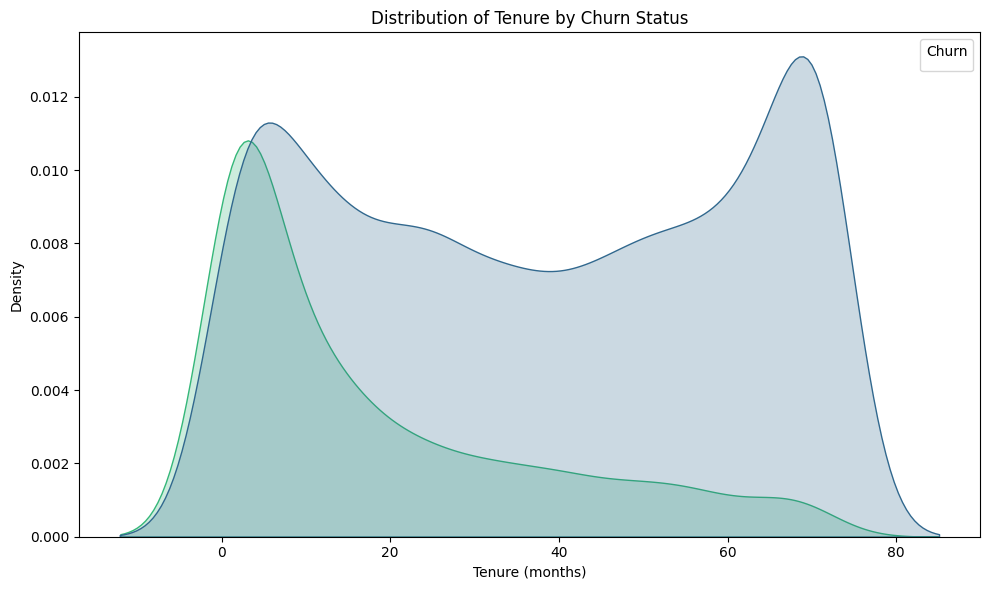

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='viridis')
plt.title('Distribution of Tenure by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous `sns.kdeplot` call generated a `UserWarning` because `plt.legend(title='Churn')` was called explicitly after `seaborn` had already created a legend automatically due to the `hue` parameter. Removing the redundant `plt.legend()` call will resolve the warning while keeping the legend, as `seaborn` correctly labels it from the `hue` variable.



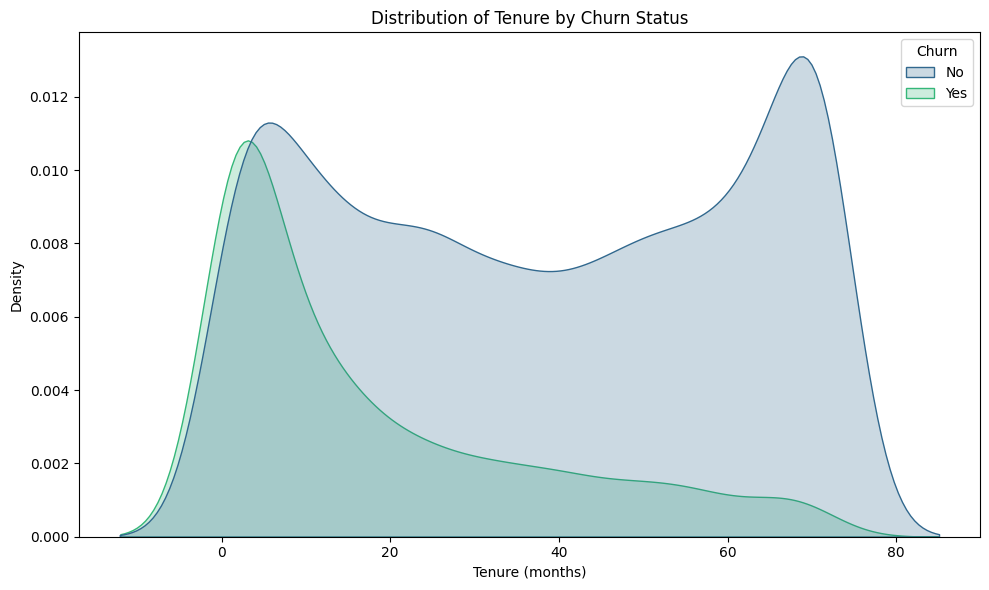

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='viridis')
plt.title('Distribution of Tenure by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of 'MonthlyCharges' for churned and non-churned customers, I will create a Kernel Density Estimate (KDE) plot using `seaborn` with 'MonthlyCharges' on the x-axis and 'Churn' as the hue, as instructed.



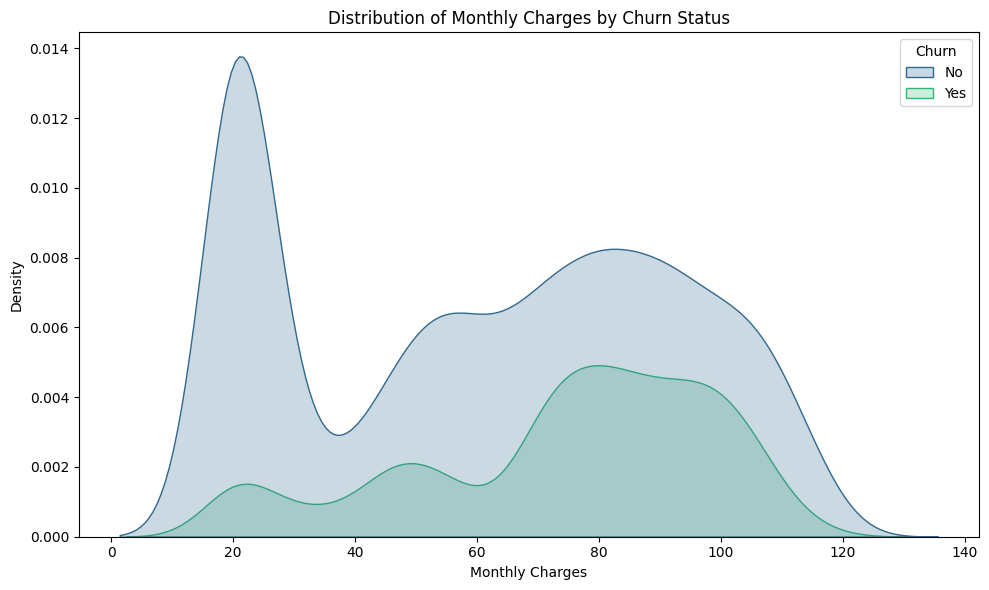

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='viridis')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Summary of Key Churn Driver Visualizations

### Contract Type vs. Churn:
*   Customers with **Month-to-month contracts** have a significantly higher churn rate compared to those with one-year or two-year contracts. This indicates that long-term contracts are a strong deterrent to churn.

### Internet Service Type vs. Churn:
*   Customers using **Fiber optic** internet service show a much higher propensity to churn than those with DSL or no internet service. This suggests potential issues or dissatisfaction with the Fiber optic offering.

### Tenure vs. Churn:
*   The KDE plot for tenure clearly shows that **customers with shorter tenures** (newer customers) are much more likely to churn. The peak density for churned customers is at very low tenure values, while non-churned customers show a distribution heavily skewed towards longer tenures.

### Monthly Charges vs. Churn:
*   The KDE plot for monthly charges indicates that **customers with higher monthly charges** tend to churn more frequently. There is a noticeable bump in churned customers at higher monthly charge values.

### Key Insights from Churn Drivers:
*   **Contract Duration**: Month-to-month contracts are a major risk factor for churn. Encouraging customers to commit to longer contracts could significantly improve retention.
*   **Internet Service Quality**: The high churn among Fiber optic users warrants investigation into service quality, pricing, or customer expectations for this service.
*   **Customer Loyalty and Engagement**: Early-stage customers (low tenure) are highly vulnerable to churn. Strategies to engage and satisfy new customers are crucial.
*   **Pricing**: Higher monthly charges correlate with increased churn. Reviewing pricing structures, especially for high-paying customers, might be beneficial.

## Summary of Key Churn Driver Visualizations

### Contract Type vs. Churn:
*   Customers with **Month-to-month contracts** have a significantly higher churn rate compared to those with one-year or two-year contracts. This indicates that long-term contracts are a strong deterrent to churn.

### Internet Service Type vs. Churn:
*   Customers using **Fiber optic** internet service show a much higher propensity to churn than those with DSL or no internet service. This suggests potential issues or dissatisfaction with the Fiber optic offering.

### Tenure vs. Churn:
*   The KDE plot for tenure clearly shows that **customers with shorter tenures** (newer customers) are much more likely to churn. The peak density for churned customers is at very low tenure values, while non-churned customers show a distribution heavily skewed towards longer tenures.

### Monthly Charges vs. Churn:
*   The KDE plot for monthly charges indicates that **customers with higher monthly charges** tend to churn more frequently. There is a noticeable bump in churned customers at higher monthly charge values.

### Key Insights from Churn Drivers:
*   **Contract Duration**: Month-to-month contracts are a major risk factor for churn. Encouraging customers to commit to longer contracts could significantly improve retention.
*   **Internet Service Quality**: The high churn among Fiber optic users warrants investigation into service quality, pricing, or customer expectations for this service.
*   **Customer Loyalty and Engagement**: Early-stage customers (low tenure) are highly vulnerable to churn. Strategies to engage and satisfy new customers are crucial.
*   **Pricing**: Higher monthly charges correlate with increased churn. Reviewing pricing structures, especially for high-paying customers, might be beneficial.

## Summary of Key Churn Driver Visualizations

### Contract Type vs. Churn:
*   Customers with **Month-to-month contracts** have a significantly higher churn rate compared to those with one-year or two-year contracts. This indicates that long-term contracts are a strong deterrent to churn.

### Internet Service Type vs. Churn:
*   Customers using **Fiber optic** internet service show a much higher propensity to churn than those with DSL or no internet service. This suggests potential issues or dissatisfaction with the Fiber optic offering.

### Tenure vs. Churn:
*   The KDE plot for tenure clearly shows that **customers with shorter tenures** (newer customers) are much more likely to churn. The peak density for churned customers is at very low tenure values, while non-churned customers show a distribution heavily skewed towards longer tenures.

### Monthly Charges vs. Churn:
*   The KDE plot for monthly charges indicates that **customers with higher monthly charges** tend to churn more frequently. There is a noticeable bump in churned customers at higher monthly charge values.

### Key Insights from Churn Drivers:
*   **Contract Duration**: Month-to-month contracts are a major risk factor for churn. Encouraging customers to commit to longer contracts could significantly improve retention.
*   **Internet Service Quality**: The high churn among Fiber optic users warrants investigation into service quality, pricing, or customer expectations for this service.
*   **Customer Loyalty and Engagement**: Early-stage customers (low tenure) are highly vulnerable to churn. Strategies to engage and satisfy new customers are crucial.
*   **Pricing**: Higher monthly charges correlate with increased churn. Reviewing pricing structures, especially for high-paying customers, might be beneficial.


## Provide Detailed Explanation and Summary

### Subtask:
Summarize all key findings from the data exploration and visualizations. Provide a comprehensive explanation of the reasons why customers are leaving, detailing the impact of various features identified as churn drivers. Include insights and potential next steps.


## Summary:

### Q&A

*   **What is the overall churn rate in the dataset?**
    The overall churn rate in the dataset is approximately 26.5%, with 1869 customers churning out of a total of 7032. Conversely, 73.5% (5163 customers) did not churn.

*   **Which categorical features are strong predictors of churn?**
    Several categorical features are strong predictors of churn:
    *   **Contract Type:** Customers on 'Month-to-month' contracts have a dramatically higher churn rate.
    *   **Internet Service:** 'Fiber optic' internet service is associated with a significantly higher churn rate.
    *   **Payment Method:** 'Electronic check' is linked to a much higher churn rate compared to other payment methods.
    *   **Support Services:** Customers without services like 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', and 'TechSupport' show considerably higher churn rates.
    *   **Partners and Dependents:** Customers without a partner and without dependents show a higher churn rate.
    *   **SeniorCitizen:** Senior Citizens have a higher propensity to churn.
    *   **PaperlessBilling:** Customers with 'PaperlessBilling' enabled show a higher churn rate.

*   **How do numerical features relate to churn?**
    *   **Tenure:** Customers with lower tenure (shorter time with the company) exhibit a significantly higher churn rate.
    *   **MonthlyCharges:** Customers with higher monthly charges tend to have a higher churn rate.
    *   **TotalCharges:** Customers with lower total charges (often correlated with lower tenure) are more likely to churn.

*   **What are the most impactful features contributing to churn?**
    The most impactful features contributing to churn, as highlighted by focused visualizations, are:
    *   **Contract Type** (specifically 'Month-to-month' contracts).
    *   **Internet Service Type** (specifically 'Fiber optic').
    *   **Tenure** (shorter tenure leads to higher churn).
    *   **MonthlyCharges** (higher charges lead to higher churn).

### Data Analysis Key Findings

*   The dataset shows a churn rate of 26.5% (1869 customers), while 73.5% (5163 customers) did not churn.
*   **Contract Type** is a major churn driver: 'Month-to-month' contracts are associated with dramatically higher churn compared to 'One year' or 'Two year' contracts.
*   **Internet Service Type** significantly impacts churn: Customers with 'Fiber optic' service have a notably higher churn rate than those with 'DSL' or no internet service.
*   **Customer Tenure** is inversely related to churn: Customers with shorter tenures are significantly more likely to churn.
*   **Monthly Charges** correlates with churn: Customers paying higher monthly fees tend to churn more frequently.
*   **Payment Method** also plays a role: 'Electronic check' is linked to a much higher churn rate compared to other payment options like automatic credit card or bank transfers.
*   **Ancillary Services** act as churn deterrents: Customers *without* 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', and 'TechSupport' exhibit considerably higher churn rates.
*   **Demographic/Household Factors:** Customers without a partner or dependents, and Senior Citizens, show a higher propensity to churn.

### Insights or Next Steps

*   **Implement Retention Strategies for At-Risk Segments:** Focus on customers with 'Month-to-month' contracts, 'Fiber optic' internet service, higher monthly charges, and shorter tenures. This could include targeted offers, service quality improvements for fiber optics, or incentives for longer-term commitments.
*   **Enhance Value Proposition of Ancillary Services:** Promote and potentially bundle 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', and 'TechSupport' to new and existing customers, as these services appear to significantly reduce churn.
